In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

#### Working with DataFrames

In [5]:
# df = pd.DataFrame(np.random.randn(5, 4))
# df = pd.DataFrame(np.random.randn(5, 4), index=['A','B','C','D','E'])
df = pd.DataFrame(np.random.randn(5, 4), index=['A','B','C','D','E'], columns=['W','X','Y','Z'])
df

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338
C,-0.035796,0.661447,0.144506,-0.573010
D,1.386854,-1.101249,-0.738924,-0.358589
E,-0.393809,-0.316007,-1.568797,-1.003476


In [6]:
# Get a Column as a Series (SQL Style)
df.W

A    0.242540
B   -0.513654
C   -0.035796
D    1.386854
E   -0.393809
Name: W, dtype: float64

In [8]:
# Get a Column as a Series (List Style)
col = 'X'
df[col]

A    0.329851
B   -0.396499
C    0.661447
D   -1.101249
E   -0.316007
Name: X, dtype: float64

#### Add a new column to the DataFrame

In [11]:
df['K'] = 1
df['K'] = df['W']
df['K'] = df['X'] + df['Y']
df

,W,X,Y,Z,K
A,0.242540,0.329851,-0.793035,1.800501,-0.463183
B,-0.513654,-0.396499,0.511840,-0.109338,0.115341
C,-0.035796,0.661447,0.144506,-0.573010,0.805954
D,1.386854,-1.101249,-0.738924,-0.358589,-1.840173
E,-0.393809,-0.316007,-1.568797,-1.003476,-1.884803


#### Drop a column from the DataFrame

In [12]:
df

,W,X,Y,Z,K
A,0.242540,0.329851,-0.793035,1.800501,-0.463183
B,-0.513654,-0.396499,0.511840,-0.109338,0.115341
C,-0.035796,0.661447,0.144506,-0.573010,0.805954
D,1.386854,-1.101249,-0.738924,-0.358589,-1.840173
E,-0.393809,-0.316007,-1.568797,-1.003476,-1.884803


In [14]:
df.drop('K', axis=1)

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338
C,-0.035796,0.661447,0.144506,-0.573010
D,1.386854,-1.101249,-0.738924,-0.358589
E,-0.393809,-0.316007,-1.568797,-1.003476


In [15]:
df

,W,X,Y,Z,K
A,0.242540,0.329851,-0.793035,1.800501,-0.463183
B,-0.513654,-0.396499,0.511840,-0.109338,0.115341
C,-0.035796,0.661447,0.144506,-0.573010,0.805954
D,1.386854,-1.101249,-0.738924,-0.358589,-1.840173
E,-0.393809,-0.316007,-1.568797,-1.003476,-1.884803


In [16]:
df.drop('K', axis=1, inplace=True) # inplace=True means that the change will be made to the original DataFrame, and not return a new DataFrame
df

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338
C,-0.035796,0.661447,0.144506,-0.573010
D,1.386854,-1.101249,-0.738924,-0.358589
E,-0.393809,-0.316007,-1.568797,-1.003476


#### Working with Rows

In [17]:
# Get a Row as a Series using row name, columns are the index of the Series
df.loc['A']

W    0.242540
X    0.329851
Y   -0.793035
Z    1.800501
Name: A, dtype: float64

In [19]:
# Get a Row as a Series using row index, columns are the index of the Series
df.iloc[0]

W    0.242540
X    0.329851
Y   -0.793035
Z    1.800501
Name: A, dtype: float64

In [20]:
df

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338
C,-0.035796,0.661447,0.144506,-0.573010
D,1.386854,-1.101249,-0.738924,-0.358589
E,-0.393809,-0.316007,-1.568797,-1.003476


In [21]:
df.loc[['A','B']] # Get multiple rows as a DataFrame using row names (all columns are fetched)

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338


In [22]:
df.loc[['A','B'],['X','Y']] # Get multiple rows as a DataFrame using row names (specified columns only are fetched)

,X,Y
A,0.329851,-0.793035
B,-0.396499,0.511840


In [23]:
df

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
B,-0.513654,-0.396499,0.511840,-0.109338
C,-0.035796,0.661447,0.144506,-0.573010
D,1.386854,-1.101249,-0.738924,-0.358589
E,-0.393809,-0.316007,-1.568797,-1.003476


In [24]:
print(df.loc['C']['X'])

0.6614472282226415


In [25]:
print(df.loc['C','X'])

0.6614472282226415


In [27]:
# Get rows where column 'W' values are greater than 0
df[df['W'] > 0]

,W,X,Y,Z
A,0.242540,0.329851,-0.793035,1.800501
D,1.386854,-1.101249,-0.738924,-0.358589


In [29]:
# Get rows where column 'W' and 'X' values are greater than 0
df[ (df['W'] > 0) & (df['X'] > 0) ]

,W,X,Y,Z
A,0.24254,0.329851,-0.793035,1.800501


#### Working with Missing data

In [4]:
df = pd.DataFrame({
            'A':[1, 2, ''], 
            'B':[4, '', ''], 
            'C':[7, 8, 9]
            })

df

,A,B,C
0,1,4,7
1,2,,8
2,,,9


In [5]:
df = pd.DataFrame({
            'A':[1, 2, np.nan], 
            'B':[4, np.nan, np.nan], 
            'C':[7, 8, 9]
            })

df

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8
2,NaN,NaN,9


In [6]:
df.dropna() # Drop rows with at least one missing value

,A,B,C
0,1.0,4.0,7


In [7]:
df.dropna(axis=1) # Drop columns with at least one missing value

,C
0,7
1,8
2,9


In [9]:
df

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8
2,NaN,NaN,9


In [10]:
df.dropna(thresh=2) # retain rows with at least 2 non-null values

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8


In [11]:
df.dropna(thresh=3) # retain rows with at least 3 non-null values

,A,B,C
0,1.0,4.0,7


In [12]:
df

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8
2,NaN,NaN,9


In [13]:
df.fillna(value=0) # Fill missing values with a specified value

,A,B,C
0,1.0,4.0,7
1,2.0,0.0,8
2,0.0,0.0,9


In [14]:
df.fillna(df.mean()) # fill the missing values with the mean of the column

,A,B,C
0,1.0,4.0,7
1,2.0,4.0,8
2,1.5,4.0,9


In [15]:
df

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8
2,NaN,NaN,9


In [16]:
df.ffill() # forward fill the missing values with the previous non missing value in the column

,A,B,C
0,1.0,4.0,7
1,2.0,4.0,8
2,2.0,4.0,9


In [17]:
df

,A,B,C
0,1.0,4.0,7
1,2.0,NaN,8
2,NaN,NaN,9


In [22]:
# Get column 'A' as a Series and fill the missing values with the mean of the column
df['A'].fillna(df['A'].mean())

0    1.0
1    2.0
2    1.5
Name: A, dtype: float64

#### GroupBy operations

In [24]:
df = pd.DataFrame({
        'Company': ['GOOG', 'GOOG', 'MSFT', 'MSFT', 'META', 'META'],
        'Person': ['John', 'Sam', 'John', 'Nancy', 'Jane', 'Mat'],
        'Sales': [200, 180, 350, 150, 250, 350]
    })

df

,Company,Person,Sales
0,GOOG,John,200
1,GOOG,Sam,180
2,MSFT,John,350
3,MSFT,Nancy,150
4,META,Jane,250
5,META,Mat,350


In [26]:
# Sum of Sales for each Company (as Series)
df.groupby('Company').sum()['Sales']

Company
GOOG    380
META    600
MSFT    500
Name: Sales, dtype: int64

In [31]:
# Sum of Sales for each Company (as Series)
df.groupby('Company')['Sales'].sum()

Company
GOOG    380
META    600
MSFT    500
Name: Sales, dtype: int64

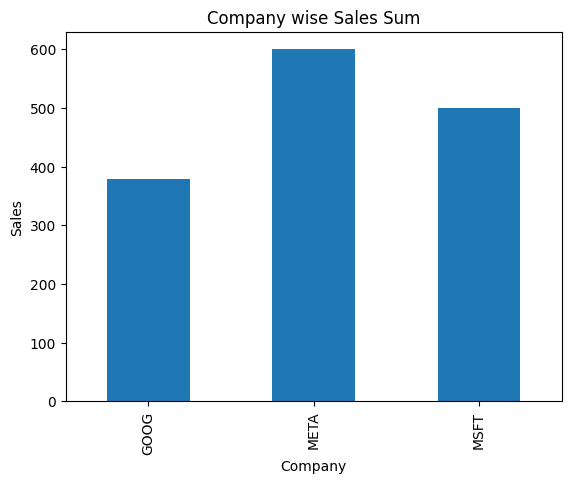

In [51]:
company_wise_sales_sum = df.groupby('Company')['Sales'].sum()
company_wise_sales_sum.plot(kind='bar', title='Company wise Sales Sum', ylabel='Sales', xlabel='Company')
plt.show()

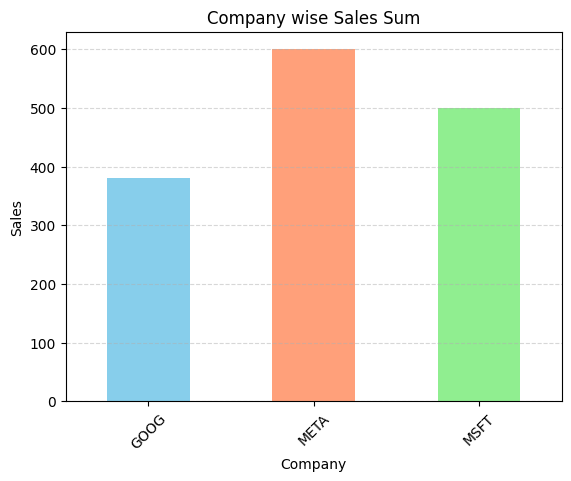

In [60]:
company_wise_sales_sum.plot(kind='bar', color=['skyblue', 'lightsalmon', 'lightgreen'])
plt.title('Company wise Sales Sum')
plt.ylabel('Sales')
plt.xlabel('Company')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<Axes: >

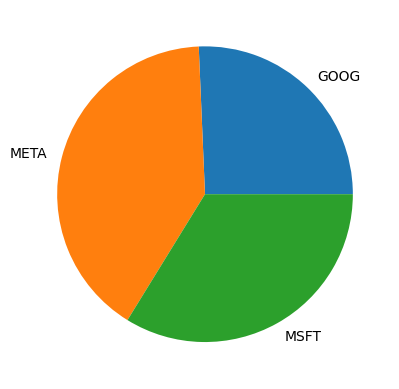

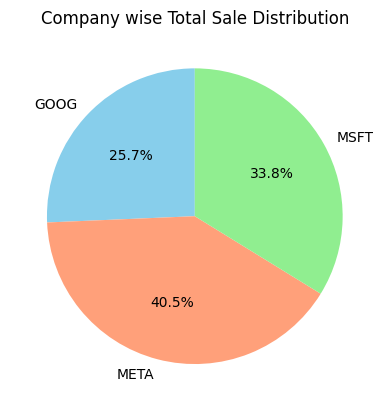

In [66]:
company_wise_sales_sum.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightsalmon', 'lightgreen'])
plt.title('Company wise Total Sale Distribution')
plt.show()

In [32]:
# Sum of Sales for each Company (as DataFrame)
df.groupby('Company').sum()[['Sales']]

,Sales
Company,
GOOG,380
META,600
MSFT,500


In [36]:
# Sum of Sales, Company wise where Sales >= 500
company_sales = df.groupby('Company').sum()['Sales']
company_sales[company_sales >= 500]

Company
META    600
MSFT    500
Name: Sales, dtype: int64

In [37]:
# Count of Sales, Company wise
df.groupby('Company').count()['Sales']

Company
GOOG    2
META    2
MSFT    2
Name: Sales, dtype: int64

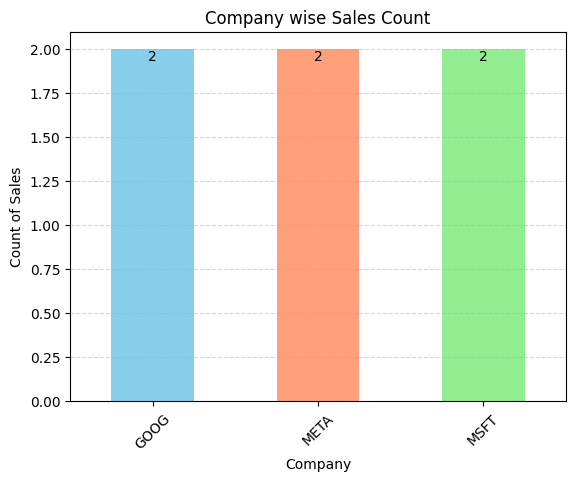

In [74]:
company_sales_count = df.groupby('Company').count()['Sales']
company_sales_count.plot(kind='bar',color=['skyblue', 'lightsalmon', 'lightgreen'])
plt.title('Company wise Sales Count')
plt.ylabel('Count of Sales')
plt.xlabel('Company')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show count in each bar
for index, value in enumerate(company_sales_count):
    plt.text(index, value, str(value), ha='center', va='top')

plt.show()

In [39]:
df

,Company,Person,Sales
0,GOOG,John,200
1,GOOG,Sam,180
2,MSFT,John,350
3,MSFT,Nancy,150
4,META,Jane,250
5,META,Mat,350


In [38]:
# Sum of Sales, Person wise
df.groupby('Person').sum()['Sales']

Person
Jane     250
John     550
Mat      350
Nancy    150
Sam      180
Name: Sales, dtype: int64

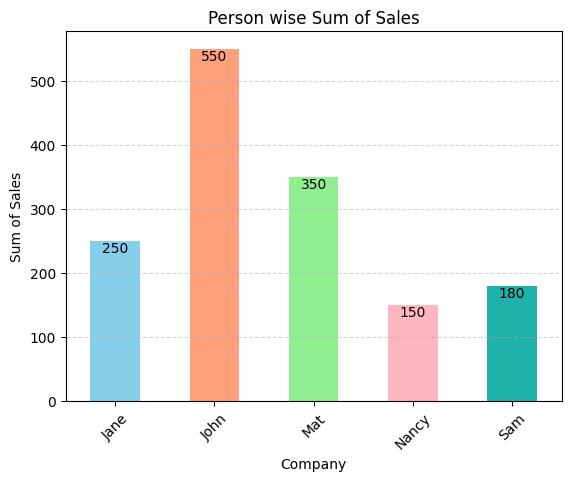

In [79]:
person_wise_sales_sum = df.groupby('Person').sum()['Sales']
person_wise_sales_sum.plot(kind='bar', color=['skyblue', 'lightsalmon', 'lightgreen', 'lightpink', 'lightseagreen'])
plt.title('Person wise Sum of Sales')
plt.ylabel('Sum of Sales')
plt.xlabel('Person')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show count in each bar
for index, value in enumerate(person_wise_sales_sum):
    plt.text(index, value, str(value), ha='center', va='top')
    
plt.show()

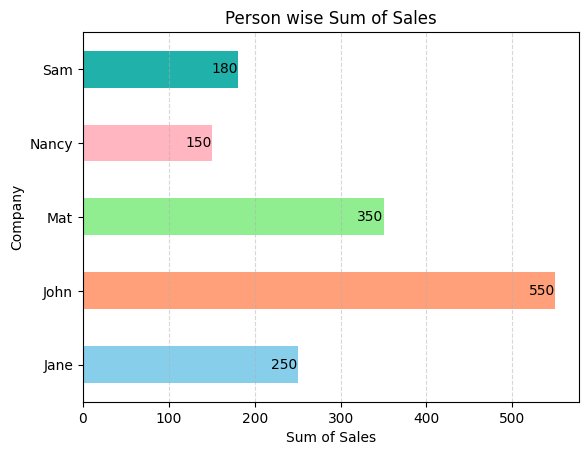

In [82]:
person_wise_sales_sum.plot(kind='barh', color=['skyblue', 'lightsalmon', 'lightgreen', 'lightpink', 'lightseagreen'])
plt.title('Person wise Sum of Sales')
plt.xlabel('Sum of Sales')
plt.ylabel('Company')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Show count in each bar
for index, value in enumerate(person_wise_sales_sum):
    plt.text(value, index, str(value), ha='right', va='center')
    
plt.show()

In [40]:
# Count of Sales, Person wise
df.groupby('Person').count()['Sales']

Person
Jane     1
John     2
Mat      1
Nancy    1
Sam      1
Name: Sales, dtype: int64

In [41]:
df

,Company,Person,Sales
0,GOOG,John,200
1,GOOG,Sam,180
2,MSFT,John,350
3,MSFT,Nancy,150
4,META,Jane,250
5,META,Mat,350


In [43]:
# Mean of Sales, Company wise (returns Series)
df.groupby('Company')['Sales'].mean()

Company
GOOG    190.0
META    300.0
MSFT    250.0
Name: Sales, dtype: float64

In [45]:
# Mean of Sales, Company wise (returns Series)
df.groupby('Company')['Sales'].agg('mean')

Company
GOOG    190.0
META    300.0
MSFT    250.0
Name: Sales, dtype: float64

In [46]:
# Mean of Sales, Company wise (returns DataFrame)
df.groupby('Company')['Sales'].agg(['mean'])

,mean
Company,
GOOG,190.0
META,300.0
MSFT,250.0


In [48]:
df.groupby('Company')['Sales'].agg(['min', 'max', 'mean', 'sum', 'count'])

,min,max,mean,sum,count
Company,,,,,
GOOG,180,200,190.0,380,2
META,250,350,300.0,600,2
MSFT,150,350,250.0,500,2


In [87]:
# Pivot Table
pivot_table = df.pivot_table(index='Person', values='Sales', aggfunc='sum', columns='Company')
pivot_table.fillna(0, inplace=True) # Fill NaN values with 0
pivot_table

Company,GOOG,META,MSFT
Person,,,
Jane,0.0,250.0,0.0
John,200.0,0.0,350.0
Mat,0.0,350.0,0.0
Nancy,0.0,0.0,150.0
Sam,180.0,0.0,0.0


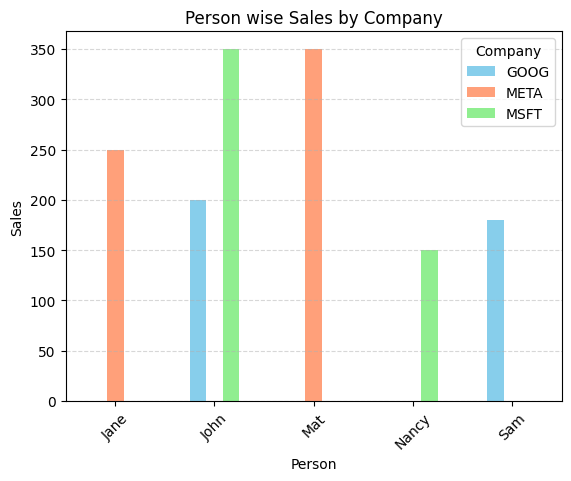

In [90]:
pivot_table.plot(kind='bar', color=['skyblue', 'lightsalmon', 'lightgreen'])
plt.title('Person wise Sales by Company')
plt.ylabel('Sales')
plt.xlabel('Person')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

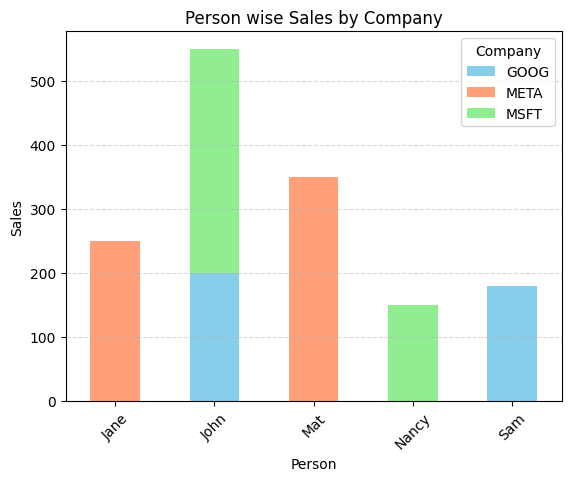

In [91]:
pivot_table.plot(kind='bar', stacked=True, color=['skyblue', 'lightsalmon', 'lightgreen'])
plt.title('Person wise Sales by Company')
plt.ylabel('Sales')
plt.xlabel('Person')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Reading and Writing DataFrames

In [92]:
df = pd.read_csv('example.csv')
df

,A,B,C,D
0,1,2,3,4
1,5,6,7,8
2,9,10,11,12
3,13,14,15,16


In [93]:
df.loc[2,'C'] = 100
df

,A,B,C,D
0,1,2,3,4
1,5,6,7,8
2,9,10,100,12
3,13,14,15,16


In [95]:
df.to_csv('example2.csv', index=False) # Save the modified DataFrame to a new CSV file without the index column
print('CSV File saved')

CSV File saved


In [ ]:
!pip install openpyxl # Install required library for reading and writing Excel files

In [96]:
df.to_excel('example.xlsx', index=False, sheet_name='My-Data') # Save the DataFrame to a Excel file without the index column
print('Excel File saved')

Excel File saved


In [98]:
# Reading from Excel file
df = pd.read_excel('example.xlsx', sheet_name='My-Data')
df

,A,B,C,D
0,111,222,333,444
1,5,6,7,8
2,9,10,100,12
3,13,14,15,16


In [100]:
df = pd.read_json('example.json') # Read from JSON file
df

,empid,ename,salary,dept,location
0,101,John,50000,HR,New York
1,102,Sam,65000,Accounts,Chicago
2,103,Jane,55000,IT,Dallas
3,104,Nancy,75000,Marketing,Los Angeles


In [ ]:
!pip install html5lib lxml # Install required libraries for reading HTML and XML files

In [103]:
url1 = 'https://www.w3schools.com/html/html_tables.asp'
df_list = pd.read_html(url1) # Read all tables from the HTML page
df = df_list[0] # Get the first table as a DataFrame
df

,Company,Contact,Country
0,Alfreds Futterkiste,Maria Anders,Germany
1,Centro comercial Moctezuma,Francisco Chang,Mexico
2,Ernst Handel,Roland Mendel,Austria
3,Island Trading,Helen Bennett,UK
4,Laughing Bacchus Winecellars,Yoshi Tannamuri,Canada
5,Magazzini Alimentari Riuniti,Giovanni Rovelli,Italy


In [104]:
url2 = 'https://www.fdic.gov/bank-failures/failed-bank-list'
df_list = pd.read_html(url2) # Read all tables from the HTML page
df = df_list[0] # Get the first table as a DataFrame
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund Sort ascending
0,Small Business Bank,Lenexa,Kansas,25744,"The Farmers State Bank of Oakley, Kansas","July 17, 2026",10553
1,Kentland Federal Savings and Loan Association,Kentland,Indiana,28722,Kentland Bank,"July 10, 2026",10552
2,Community Bank and Trust - West Georgia,LaGrange,Georgia,25796,Anchor Bank,"May 1, 2026",10551
3,Metropolitan Capital Bank & Trust,Chicago,Illinois,57488,First Independence Bank,"January 30, 2026",10550
4,The Santa Anna National Bank,Santa Anna,Texas,5520,Coleman County State Bank,"June 27, 2025",10549
5,Pulaski Savings Bank,Chicago,Illinois,28611,Millennium Bank,"January 17, 2025",10548
6,The First National Bank of Lindsay,Lindsay,Oklahoma,4134,First Bank & Trust Co.,"October 18, 2024",10547
7,Republic First Bank dba Republic Bank,Philadelphia,Pennsylvania,27332,"Fulton Bank, National Association","April 26, 2024",10546
8,Citizens Bank,Sac City,Iowa,8758,Iowa Trust & Savings Bank,"November 3, 2023",10545
9,Heartland Tri-State Bank,Elkhart,Kansas,25851,"Dream First Bank, N.A.","July 28, 2023",10544


In [109]:
df = pd.read_csv('bank-data.csv', encoding='windows-1252') # Read CSV file
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [110]:
df.head() # top 5 rows

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549


In [111]:
df.head(10) # top 10 rows

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,17-Jan-25,10548
6,The First National Bank of Lindsay,Lindsay,OK,4134,First Bank & Trust Co.,18-Oct-24,10547
7,Republic First Bank dba Republic Bank,Philadelphia,PA,27332,"Fulton Bank, National Association",26-Apr-24,10546
8,Citizens Bank,Sac City,IA,8758,Iowa Trust & Savings Bank,3-Nov-23,10545
9,Heartland Tri-State Bank,Elkhart,KS,25851,"Dream First Bank, N.A.",28-Jul-23,10544


In [112]:
df.tail() # bottom 5 rows

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646
575,Bank of Honolulu,Honolulu,HI,21029,Bank of the Orient,13-Oct-00,4645


In [113]:
df.tail(10) # bottom 10 rows

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
566,"NextBank, NA",Phoenix,AZ,22314,No Acquirer,7-Feb-02,4653
567,Oakwood Deposit Bank Co.,Oakwood,OH,8966,The State Bank & Trust Company,1-Feb-02,4652
568,Bank of Sierra Blanca,Sierra Blanca,TX,22002,The Security State Bank of Pecos,18-Jan-02,4651
569,"Hamilton Bank, N.A.",Miami,FL,24382,Israel Discount Bank of New York,11-Jan-02,4650
570,Sinclair National Bank,Gravette,AR,34248,Delta Trust & Bank,7-Sep-01,4649
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646
575,Bank of Honolulu,Honolulu,HI,21029,Bank of the Orient,13-Oct-00,4645


In [114]:
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [115]:
len(df) # number of rows

576

In [116]:
df.info() # Get information about the DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Bank Name               576 non-null    str  
 1   City                    576 non-null    str  
 2   State                   576 non-null    str  
 3   Cert                    576 non-null    int64
 4   Acquiring Institution   576 non-null    str  
 5   Closing Date            576 non-null    str  
 6   Fund                    576 non-null    int64
dtypes: int64(2), str(5)
memory usage: 31.6 KB


In [117]:
df.columns # Get the column names of the DataFrame

Index(['Bank Name ', 'City ', 'State ', 'Cert ', 'Acquiring Institution ',
       'Closing Date ', 'Fund'],
      dtype='str')

In [118]:
df.columns = df.columns.str.strip() # Remove leading and trailing spaces from column names
df.columns

Index(['Bank Name', 'City', 'State', 'Cert', 'Acquiring Institution',
       'Closing Date', 'Fund'],
      dtype='str')

In [119]:
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [120]:
df[df['State'] == 'IL'] # Filter rows where State is 'IL'

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,17-Jan-25,10548
21,Washington Federal Bank for Savings,Chicago,IL,30570,Royal Savings Bank,15-Dec-17,10530
23,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,10528
27,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,10524
...,...,...,...,...,...,...,...
523,National Bank of Commerce,Berkeley,IL,19733,Republic Bank of Chicago,16-Jan-09,10028
534,Meridian Bank,Eldred,IL,13789,National Bank,10-Oct-08,10017
562,Universal Federal Savings Bank,Chicago,IL,29355,Chicago Community Bank,27-Jun-02,6005
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004


In [122]:
pd.set_option('display.max_rows', 100) # Set the maximum number of rows to display
df[df['State'] == 'IL']['Bank Name']

3                      Metropolitan Capital Bank & Trust
5                                   Pulaski Savings Bank
21                   Washington Federal Bank for Savings
23                                   Fayette County Bank
27                         Seaway Bank and Trust Company
37                                        Edgebrook Bank
40                               Highland Community Bank
44                 The National Republic Bank of Chicago
46                                 GreenChoice Bank, fsb
50                                           Valley Bank
53                                     AztecAmerica Bank
59                                  DuPage National Bank
81                                         Covenant Bank
86                          Citizens First National Bank
92                                     First United Bank
95                                 Waukegan Savings Bank
97     Second Federal Savings and Loan Association of...
108                     Farmers

In [123]:
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [124]:
df.groupby('State').count()['Bank Name'] # Count of banks in each state

State
AL     7
AR     4
AZ    16
CA    43
CO    10
CT     2
FL    76
GA    94
HI     1
IA     3
ID     2
IL    71
IN     4
KS    13
KY     3
LA     4
MA     1
MD    10
MI    14
MN    23
MO    16
MS     2
NC     7
NE     4
NH     1
NJ     8
NM     3
NV    12
NY     6
OH     9
OK     8
OR     6
PA    11
PR     4
SC    10
SD     1
TN     7
TX    14
UT     8
VA     5
WA    19
WI    11
WV     2
WY     1
Name: Bank Name, dtype: int64

In [126]:
df.groupby('State').count()['Bank Name'].sort_values(ascending=False) # Count of banks in each state sorted in descending order

State
GA    94
FL    76
IL    71
CA    43
MN    23
WA    19
AZ    16
MO    16
MI    14
TX    14
KS    13
NV    12
WI    11
PA    11
SC    10
MD    10
CO    10
OH     9
OK     8
UT     8
NJ     8
AL     7
TN     7
NC     7
NY     6
OR     6
VA     5
AR     4
PR     4
LA     4
IN     4
NE     4
KY     3
NM     3
IA     3
CT     2
MS     2
ID     2
WV     2
HI     1
NH     1
MA     1
SD     1
WY     1
Name: Bank Name, dtype: int64

In [127]:
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [129]:
df2 = df[['Bank Name', 'State']]
df2

,Bank Name,State
0,Small Business Bank,KS
1,Kentland Federal Savings and Loan Association,IN
2,Community Bank and Trust - West Georgia,GA
3,Metropolitan Capital Bank & Trust,IL
4,The Santa Anna National Bank,TX
...,...,...
571,"Superior Bank, FSB",IL
572,Malta National Bank,OH
573,First Alliance Bank & Trust Co.,NH
574,The National State Bank of Metropolis,IL


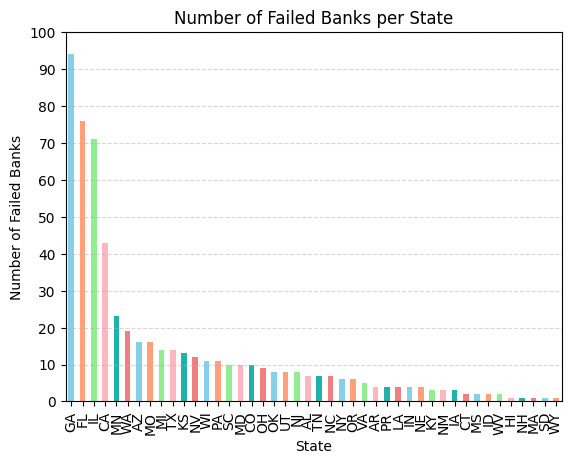

In [135]:
statewise_bank_count = df.groupby('State').count()['Bank Name'].sort_values(ascending=False)
statewise_bank_count.plot(kind='bar', color=['skyblue', 'lightsalmon', 'lightgreen', 'lightpink', 'lightseagreen', 'lightcoral'])
plt.title('Number of Failed Banks per State')
plt.xlabel('State')
plt.ylabel('Number of Failed Banks')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(range(0,101,10))
plt.show()

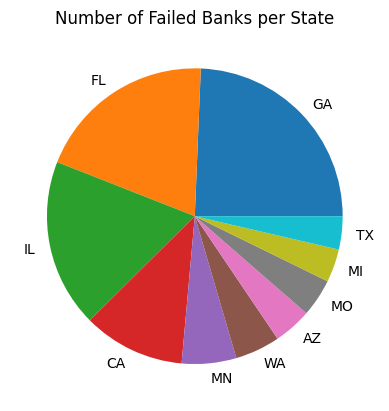

In [140]:
statewise_bank_count.head(10).plot(kind='pie')
plt.title('Number of Failed Banks per State')
plt.show()

In [141]:
df

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",17-Jul-26,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,10-Jul-26,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,1-May-26,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,30-Jan-26,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,27-Jun-25,10549
...,...,...,...,...,...,...,...
571,"Superior Bank, FSB",Hinsdale,IL,32646,"Superior Federal, FSB",27-Jul-01,6004
572,Malta National Bank,Malta,OH,6629,North Valley Bank,3-May-01,4648
573,First Alliance Bank & Trust Co.,Manchester,NH,34264,Southern New Hampshire Bank & Trust,2-Feb-01,4647
574,The National State Bank of Metropolis,Metropolis,IL,3815,Banterra Bank of Marion,14-Dec-00,4646


In [142]:
# Convert 'Closing Date' column to datetime format
df['Closing Date'] = pd.to_datetime(df['Closing Date'])

/tmp/ipykernel_6104/63700132.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closing Date'] = pd.to_datetime(df['Closing Date'])


In [143]:
df.info() # Get information about the DataFrame after converting 'Closing Date' to datetime format

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              576 non-null    str           
 1   City                   576 non-null    str           
 2   State                  576 non-null    str           
 3   Cert                   576 non-null    int64         
 4   Acquiring Institution  576 non-null    str           
 5   Closing Date           576 non-null    datetime64[us]
 6   Fund                   576 non-null    int64         
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 31.6 KB


In [144]:
# Banks which have failed in the year 2025
df[df['Closing Date'].dt.year == 2025]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,2025-06-27,10549
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,2025-01-17,10548


In [145]:
# Banks which have failed in the year 2025 and beyond
df[df['Closing Date'].dt.year >= 2025]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
0,Small Business Bank,Lenexa,KS,25744,"The Farmers State Bank of Oakley, Kansas",2026-07-17,10553
1,Kentland Federal Savings and Loan Association,Kentland,IN,28722,Kentland Bank,2026-07-10,10552
2,Community Bank and Trust - West Georgia,LaGrange,GA,25796,Anchor Bank,2026-05-01,10551
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,2026-01-30,10550
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,2025-06-27,10549
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,2025-01-17,10548


In [147]:
# Banks which have failed in the years 2023 and 2025
df[df['Closing Date'].dt.year.isin([2023, 2025])]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
4,The Santa Anna National Bank,Santa Anna,TX,5520,Coleman County State Bank,2025-06-27,10549
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,2025-01-17,10548
8,Citizens Bank,Sac City,IA,8758,Iowa Trust & Savings Bank,2023-11-03,10545
9,Heartland Tri-State Bank,Elkhart,KS,25851,"Dream First Bank, N.A.",2023-07-28,10544
10,First Republic Bank,San Francisco,CA,59017,"JPMorgan Chase Bank, N.A.",2023-05-01,10543
11,Signature Bank,New York,NY,57053,"Flagstar Bank, N.A.",2023-03-12,10540
12,Silicon Valley Bank,Santa Clara,CA,24735,First–Citizens Bank & Trust Company,2023-03-10,10539


In [149]:
# Banks which have failed in the year 2025 and beyond in the state of 'IL'
df[ (df['Closing Date'].dt.year >= 2025) & (df['State'] == 'IL') ]

,Bank Name,City,State,Cert,Acquiring Institution,Closing Date,Fund
3,Metropolitan Capital Bank & Trust,Chicago,IL,57488,First Independence Bank,2026-01-30,10550
5,Pulaski Savings Bank,Chicago,IL,28611,Millennium Bank,2025-01-17,10548
